# Figure 4 three-arm synthetic fitting tutorial
## No radiation + 10 Gy (50%) + 10 Gy (100%)

이 노트북은 Cho et al. Figure 4 계열 실험을 예제로 사용합니다. 수식과 분석 흐름은 노트북에서 설명하고, 재사용 가능한 구현은 `src/radioimmune_modeling/` 패키지에서 불러옵니다.

1. 일반화된 radio-immune forward model을 수식으로 설명하고 패키지 API로 실행
2. `no radiation`, `10 Gy / 50%`, `10 Gy / 100%` 세 arm 생성
3. multiplicative log-normal noise 추가
4. 네 파라미터 $\theta=(\mu,\omega,\psi,\kappa)$를 모든 arm에 동시에 fitting
5. Differential Evolution으로 전역 탐색
6. bounded nonlinear Least Squares로 국소 정밀화
7. Jacobian, parameter correlation, profile cost, 반복 noise 실험으로 identifiability 확인

이 노트북의 목적은 “한 번의 최적화에서 true value와 비슷한 값이 나왔다”에서 끝나지 않고, **어떤 파라미터가 실제로 데이터에 의해 결정되는지**까지 확인하는 것입니다.

> 기준 모델: `ref/code/PaperFig04.m` 및 Cho et al. (2023), Figure 4 parameter set


## 1. 세 arm을 동시에 사용하는 이유

관측값은 각 arm $a$에서 측정한 총 종양 부피입니다.

$$
V_a(t)=\sum_{j=1}^{M}\left[T_{a,j}(t)+D_{a,j}(t)\right].
\tag{1}
$$

세 arm의 역할은 서로 다릅니다.

| Arm | 주로 제공하는 정보 |
|---|---|
| No radiation | 고유 성장률 $\mu$, baseline immune dynamics |
| 10 Gy, 50% | 종양 손상과 면역세포 보존의 균형 |
| 10 Gy, 100% | 강한 direct kill과 면역세포 손상 |
| 50%와 100%의 차이 | radiation-induced immune activation $\psi$ |
| 후기 regrowth | immune suppression $\kappa$ |

모든 arm은 동일한 생물학적 파라미터를 공유하고, dose와 coverage만 다르게 둡니다. 이렇게 해야 optimizer가 arm마다 별도의 파라미터로 noise를 설명하는 것을 막을 수 있습니다.


## 2. 상태변수와 방사선 생존분율

시간은 하루 단위 $n=0,\ldots,N-1$, 공간 구간은 $j=1,\ldots,M$입니다.

- $T_{n,j}$: viable tumor
- $D_{n,j}$: doomed tumor
- $L_{n,j}$: active lymphocytes/CTLs
- $A_{n,j}$: immune-triggering-cell density
- $Z_n^p$: primary immune effect
- $Z_n^s$: secondary immune effect
- $\varepsilon_n$: radiation-induced activation fraction

### Linear–quadratic radiation response

공간 구간 $j$에 day $n$의 dose $d_{n,j}$가 주어지면

$$
H^T_{n,j}=\alpha_Td_{n,j}+\beta_Td_{n,j}^2,
\qquad
H^L_{n,j}=\alpha_Ld_{n,j}+\beta_Ld_{n,j}^2.
\tag{2}
$$

CTL은 같은 날 손상된다고 가정하므로

$$
S^L_{n,j}=\exp(-H^L_{n,j}).
\tag{3}
$$

종양 사멸에는 평균 $\bar t=3$ day, 표준편차 $\sigma_t=1.5$ day의 지연을 적용합니다.

$$
\widetilde w_m=
\frac{1}{\sigma_t\sqrt{2\pi}}
\exp\left[-\frac12\left(\frac{m-\bar t}{\sigma_t}\right)^2\right],
\qquad
w_0=1-\sum_{m=1}^{N-1}\widetilde w_m.
\tag{4}
$$

누적 delayed hazard와 tumor surviving fraction은

$$
\mathcal H^T_{n,j}
=
\sum_{\tau=0}^{n}H^T_{\tau,j}w_{n-\tau},
\qquad
S^T_{n,j}=\exp(-\mathcal H^T_{n,j}).
\tag{5}
$$

Python에서는 식 (5)를 `np.convolve`로 계산합니다.


실제 구현은 `src/radioimmune_modeling/model.py`에 있으며, 이 노트북은 공개 API를 호출해 각 수식과 결과를 연결합니다.

## 3. 하루 단위 radio-immune recurrence

현재 면역효과는

$$
Z_n=Z_n^p+Z_n^s
\tag{6}
$$

이고 viable tumor는

$$
T_{n+1,j}
=
T_{n,j}S^T_{n,j}\exp(\mu-Z_n)
\tag{7}
$$

로 변합니다.

Radiation-damaged fraction으로 activation을 계산합니다.

$$
\varepsilon_{n+1}
=
0.999\tanh\left[
s\,
\frac{
\sum_j(1-S^T_{n,j})T_{n,j}
}{
\sum_j(T_{n,j}+D_{n,j})
}
\right].
\tag{8}
$$

Triggering-cell density와 CTL recurrence는

$$
A_{n+1,j}
=
\left[
\frac{S^L_{n,j}}{S^T_{n,j}}A_{n,j}
+
\lambda_A(1-A_{n,j})
\right]
(1-\varepsilon_{n+1}),
\tag{9}
$$

$$
\begin{aligned}
L_{n+1,j}
={}&(1-\lambda_L)S^L_{n,j}L_{n,j}\\
&+\rho T_{n+1,j}\\
&+\psi\varepsilon_{n+1}A_{n+1,j}T_{n+1,j}.
\end{aligned}
\tag{10}
$$

Primary immune effect에는 tumor surface-area scaling과 immune suppression이 들어갑니다.

$$
Z^p_{n+1}
=
\frac{
\omega\sum_jL_{n+1,j}
}{
1+
\displaystyle
\frac{
\kappa
\left(\sum_jT_{n+1,j}\right)^{2/3}
\sum_jL_{n+1,j}
}{
1+p_{n+1}
}
}.
\tag{11}
$$

Secondary immune response는

$$
Z^s_{n+1}
=
Z^s_n
+
\gamma
\frac{1+c_4}{r+c_4}
Z^p_{n+1}.
\tag{12}
$$

Figure 4에서는 $\gamma=p_n=c_4=0$이므로 $Z_n^s=0$입니다.

마지막으로 doomed tumor는

$$
\begin{aligned}
D_{n+1,j}
={}&(1-\lambda_T)D_{n,j}\\
&+(1-S^T_{n,j})T_{n,j}\\
&+S^T_{n,j}T_{n,j}e^\mu(1-e^{-Z_n}).
\end{aligned}
\tag{13}
$$

두 번째 항은 radiation kill, 세 번째 항은 immune kill입니다.


In [1]:
from dataclasses import asdict
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().resolve()
while (
    repo_root != repo_root.parent
    and not (repo_root / "src" / "radioimmune_modeling").exists()
):
    repo_root = repo_root.parent

src_root = repo_root / "src"
if not (src_root / "radioimmune_modeling").exists():
    raise RuntimeError("Could not locate src/radioimmune_modeling")
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from radioimmune_modeling import (
    DEFAULT_VOLUME_FIT_SPECS,
    STANDARD_THREE_ARMS,
    ModelParameters,
    build_dose_schedule,
    chi_square,
    clearance_weights,
    dataset_from_frame,
    fit_dataset,
    generate_synthetic_dataset,
    local_uncertainty_summary,
    log_bounds,
    parameter_recovery_table,
    profile_parameter,
    repeated_noise_recovery,
    residual_vector,
    simulate,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 6)


## 4. 고정 파라미터와 true fitting 파라미터

전체 tumor-volume 데이터만으로는 모든 파라미터를 동시에 식별할 수 없습니다. 이 튜토리얼에서는

$$
\boxed{\theta=(\mu,\omega,\psi,\kappa)}
\tag{14}
$$

만 fitting합니다.

- $\mu$: tumor growth rate
- $\omega$: CTL-to-killing efficiency
- $\psi$: radiation-induced infiltration/activation
- $\kappa$: immune suppression

다음은 문헌 또는 실험 설계값으로 고정합니다.

$$
\rho,\;
\alpha_T,\beta_T,\alpha_L,\beta_L,\;
\lambda_T,\lambda_L,\lambda_A,\;
\gamma,r,s,\;
d_{\mathrm{RT}},t_{\mathrm{RT}}.
$$

특히 10 Gy 한 dose만으로는

$$
-\log S_{10}=10\alpha+100\beta
\tag{15}
$$

한 조합만 관측되므로 $\alpha$와 $\beta$를 동시에 fitting할 수 없습니다.


In [2]:
TRUE_PARAMS = ModelParameters(
    n_days=61,
    n_bins=2,
)
pd.DataFrame(
    {
        "parameter": asdict(TRUE_PARAMS).keys(),
        "value": asdict(TRUE_PARAMS).values(),
    }
)


,parameter,value
0,alpha_t,0.050000
1,beta_t,0.011364
2,alpha_l,0.182000
3,beta_l,0.143000
4,mu,0.216608
5,lambda_t,0.045158
6,lambda_a,0.045158
7,lambda_l,0.045158
8,rho,0.500000
9,psi,300.000000


공간 bin은 두 개만 사용합니다.

$$
M=2.
$$

- coverage $0$: 두 bin 모두 0 Gy
- coverage $0.5$: 한 bin은 10 Gy, 한 bin은 0 Gy
- coverage $1$: 두 bin 모두 10 Gy

각 bin의 초기 부피가 같기 때문에 이것은 정확한 0%, 50%, 100% volume coverage입니다. 균일한 두 dose level만 필요한 Figure 4 synthetic experiment에서는 100개 bin과 동일한 aggregate dynamics를 훨씬 빠르게 계산합니다.


In [3]:
weights = clearance_weights(TRUE_PARAMS)
dose_50 = build_dose_schedule(TRUE_PARAMS, coverage=0.5)
dose_100 = build_dose_schedule(TRUE_PARAMS, coverage=1.0)

assert np.isclose(weights.sum(), 1.0)
assert np.count_nonzero(dose_50[TRUE_PARAMS.treatment_day]) == 1
assert np.count_nonzero(dose_100[TRUE_PARAMS.treatment_day]) == 2

pd.DataFrame(
    {
        "coverage": [0.5, 1.0],
        "irradiated_bins": [
            np.count_nonzero(dose_50[TRUE_PARAMS.treatment_day]),
            np.count_nonzero(dose_100[TRUE_PARAMS.treatment_day]),
        ],
        "dose_gy": [dose_50.max(), dose_100.max()],
    }
)


,coverage,irradiated_bins,dose_gy
0,0.5,1,10.0
1,1.0,2,10.0


In [4]:
simulation_check = simulate(TRUE_PARAMS, coverage=0.5)
assert simulation_check.viable.shape == (
    TRUE_PARAMS.n_days,
    TRUE_PARAMS.n_bins,
)
assert np.isclose(
    simulation_check.total_volume[0],
    TRUE_PARAMS.initial_volume,
)
assert np.all(np.isfinite(simulation_check.total_volume))
print("Forward-model API checks passed.")


Forward-model API checks passed.


## 5. Noise가 없는 세 arm의 forward trajectories

치료일을 기준으로 상대시간을

$$
\tau=n-n_{\mathrm{RT}}
\tag{16}
$$

로 정의합니다. 실제 fitting에는 치료 후 $\tau=0,3,\ldots,30$ day를 사용합니다.


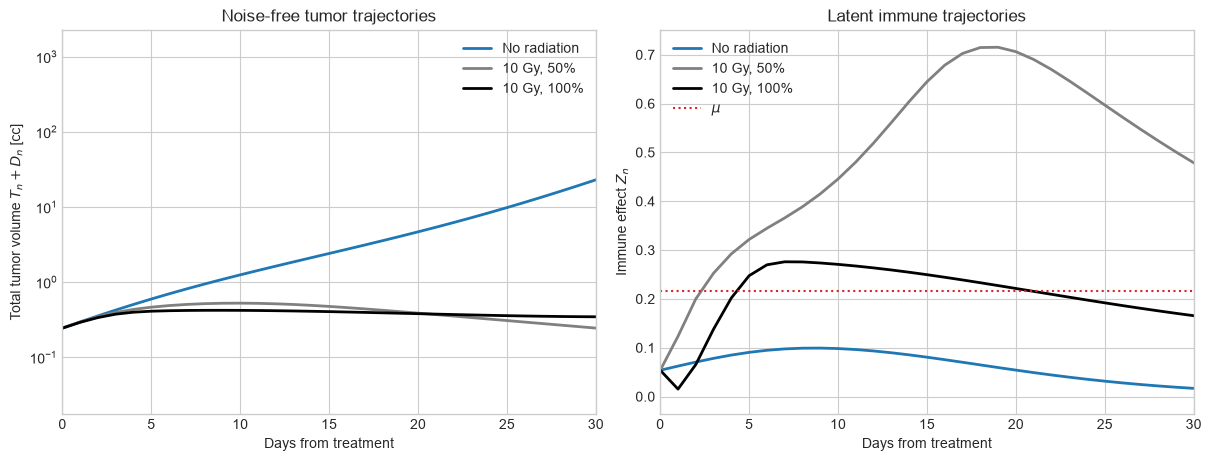

In [ ]:
ARMS = STANDARD_THREE_ARMS
ARM_COLORS = {
    "No radiation": "tab:blue",
    "10 Gy, 50%": "0.50",
    "10 Gy, 100%": "black",
}

true_results = {
    arm.name: simulate(TRUE_PARAMS, arm.coverage)
    for arm in ARMS
}

relative_axis = (
    np.arange(TRUE_PARAMS.n_days)
    - TRUE_PARAMS.treatment_day
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
    constrained_layout=True,
)
for arm in ARMS:
    result = true_results[arm.name]
    color = ARM_COLORS[arm.name]
    axes[0].plot(
        relative_axis,
        result.total_volume,
        color=color,
        lw=2,
        label=arm.name,
    )
    axes[1].plot(
        relative_axis,
        result.immune_effect,
        color=color,
        lw=2,
        label=arm.name,
    )

axes[0].set(
    xlim=(0, 30),
    yscale="log",
    xlabel="Days from treatment",
    ylabel=r"Total tumor volume $T_n+D_n$ [cc]",
    title="Noise-free tumor trajectories",
)
axes[1].axhline(
    TRUE_PARAMS.mu,
    color="tab:red",
    ls=":",
    lw=1.5,
    label=r"$\mu$",
)
axes[1].set(
    xlim=(0, 30),
    xlabel="Days from treatment",
    ylabel=r"Immune effect $Z_n$",
    title="Latent immune trajectories",
)
axes[0].legend()
axes[1].legend()
plt.show()


## 6. Synthetic multiplicative noise

종양 부피는 양수이고 measurement error가 부피 크기에 비례하는 경우가 많으므로 log-normal noise를 사용합니다.

$$
\log V_{a,i}^{\mathrm{obs}}
=
\log V_{a,i}^{\mathrm{true}}
+
\eta_{a,i},
\qquad
\eta_{a,i}\sim\mathcal N(0,\sigma_{\log V}^2).
\tag{17}
$$

따라서

$$
V_{a,i}^{\mathrm{obs}}
=
V_{a,i}^{\mathrm{true}}
\exp(\eta_{a,i}).
\tag{18}
$$

여기서는

$$
\sigma_{\log V}=0.06
$$

을 사용합니다. 이는 작은 noise에서 대략 6% multiplicative scatter에 해당합니다.


In [6]:
OBSERVATION_DAYS = np.arange(0, 31, 3)
DATASET = generate_synthetic_dataset(
    TRUE_PARAMS,
    relative_days=OBSERVATION_DAYS,
    log_sigma=0.06,
    seed=29,
    arms=ARMS,
)

pd.DataFrame(
    [
        {
            "arm": arm.name,
            "coverage": arm.coverage,
            "dose_gy": arm.dose_gy,
            "treatment_day": arm.treatment_day,
            "n_points": len(arm.relative_days),
            "first_day": arm.relative_days.min(),
            "last_day": arm.relative_days.max(),
            "log_sigma": np.asarray(arm.log_sigma).mean(),
        }
        for arm in DATASET.arms
    ]
)


,arm,coverage,dose_gy,treatment_day,n_points,first_day,last_day,log_sigma
0,No radiation,0.0,0.0,10,11,0,30,0.06
1,"10 Gy, 50%",0.5,10.0,10,11,0,30,0.06
2,"10 Gy, 100%",1.0,10.0,10,11,0,30,0.06


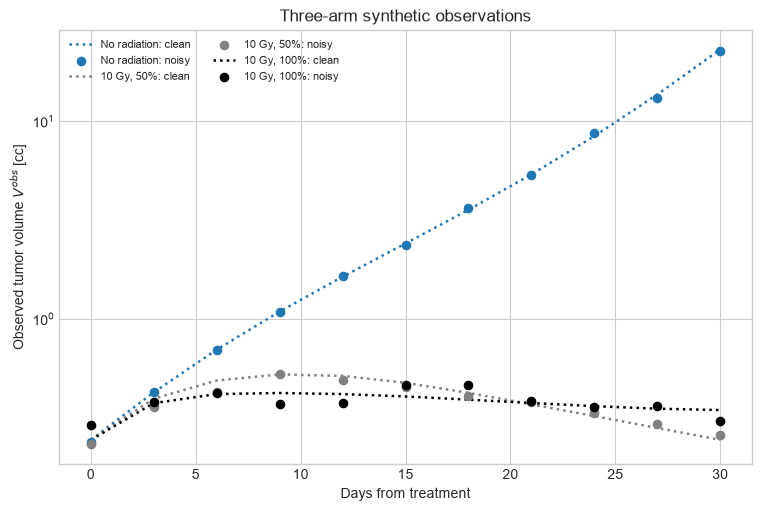

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 5), constrained_layout=True)

for arm in DATASET.arms:
    color = ARM_COLORS[arm.name]
    ax.plot(
        arm.relative_days,
        arm.clean_volume,
        color=color,
        ls=":",
        lw=1.8,
        label=f"{arm.name}: clean",
    )
    ax.scatter(
        arm.relative_days,
        arm.observed_volume,
        color=color,
        s=35,
        label=f"{arm.name}: noisy",
        zorder=3,
    )

ax.set(
    yscale="log",
    xlabel="Days from treatment",
    ylabel=r"Observed tumor volume $V^{obs}$ [cc]",
    title="Three-arm synthetic observations",
)
ax.legend(fontsize=8, ncol=2)
plt.show()


## 7. 왜 $\rho$는 고정하는가?

방사선이 없고 immune suppression이 아직 작을 때

$$
L_{n+1}\approx(1-\lambda_L)L_n+\rho T_{n+1},
\qquad
Z_n^p\approx\omega L_n.
\tag{19}
$$

따라서 no-radiation volume은 주로

$$
g_0=\omega\rho
\tag{20}
$$

에 민감합니다.

조사 후에는

$$
L_{n+1}^{RT}
\supset
\psi\varepsilon_{n+1}A_{n+1}T_{n+1},
\tag{21}
$$

이므로 radiation-induced immune effect는 주로

$$
g_{RT}=\omega\psi
\tag{22}
$$

에 민감합니다.

즉 volume-only 데이터에서 $\rho,\omega,\psi$를 모두 풀면 강한 parameter ridge가 생깁니다. 여기서는 논문값

$$
\rho=0.5
$$

를 고정하고 $\omega,\psi$를 fitting합니다.


## 8. Log-parameter optimization

파라미터의 단위와 크기가 크게 다릅니다.

$$
\mu\sim10^{-1},\quad
\omega\sim10^{-1},\quad
\psi\sim10^2,\quad
\kappa\sim10^0.
$$

따라서 optimizer는 자연 파라미터 대신

$$
u_j=\log\theta_j
\tag{23}
$$

를 탐색합니다. 이 방식은 positivity를 자동으로 보장하고, additive step이 상대적 변화로 해석되게 합니다.


In [8]:
FIT_SPECS = DEFAULT_VOLUME_FIT_SPECS
LOG_BOUNDS = log_bounds(FIT_SPECS)

pd.DataFrame(
    {
        "parameter": [spec.name for spec in FIT_SPECS],
        "lower": [spec.lower for spec in FIT_SPECS],
        "true": [
            getattr(TRUE_PARAMS, spec.name)
            for spec in FIT_SPECS
        ],
        "upper": [spec.upper for spec in FIT_SPECS],
    }
)


,parameter,lower,true,upper
0,mu,0.023105,0.216608,0.462098
1,omega,0.010000,0.135000,0.300000
2,psi,10.000000,300.000000,800.000000
3,kappa,0.050000,1.100000,2.500000


## 9. Residual과 목적함수

Arm $a$, 관측점 $i$의 standardized log residual은

$$
r_{a,i}(\theta)
=
\frac{
\log V_a^{pred}(t_i;\theta)
-
\log V_{a,i}^{obs}
}{
\sigma_{\log V,a}
}.
\tag{24}
$$

모든 arm의 residual을 하나의 벡터로 연결합니다.

$$
\mathbf r(\theta)
=
\begin{bmatrix}
\mathbf r_{\mathrm{noRT}}\\
\mathbf r_{50\%}\\
\mathbf r_{100\%}
\end{bmatrix}.
\tag{25}
$$

최소화할 목적함수는

$$
\chi^2(\theta)=
\|\mathbf r(\theta)\|_2^2.
\tag{26}
$$

Synthetic identifiability를 정직하게 검사하기 위해 이 단계에서는 prior residual을 넣지 않습니다.


In [9]:
TRUE_LOG_VALUES = np.log(
    [getattr(TRUE_PARAMS, spec.name) for spec in FIT_SPECS]
)
TRUTH_RESIDUALS = residual_vector(
    TRUE_LOG_VALUES,
    DATASET,
    TRUE_PARAMS,
    FIT_SPECS,
)
print(f"Number of residuals = {len(TRUTH_RESIDUALS)}")
print(
    "Chi-square at generating parameters = "
    f"{chi_square(TRUE_LOG_VALUES, DATASET, TRUE_PARAMS, FIT_SPECS):.6f}"
)


Number of residuals = 33
Chi-square at generating parameters = 46.781678


## 10. Differential Evolution → Least Squares

첫 단계에서는 Differential Evolution이 bounded global search를 수행합니다.

$$
u_{\mathrm{DE}}
=
\arg\min_{u\in[\log\theta_L,\log\theta_U]}
\chi^2(e^u).
\tag{27}
$$

두 번째 단계에서는 DE 해를 초기값으로 bounded trust-region least squares를 실행합니다.

$$
u_{\mathrm{LS}}
=
\arg\min_u
\frac12\|\mathbf r(e^u)\|_2^2,
\qquad
u_0=u_{\mathrm{DE}}.
\tag{28}
$$

DE는 non-convex basin을 찾고, Least Squares는 residual vector와 local Jacobian을 이용해 해를 정밀화합니다.


In [10]:
FIT_RESULT = fit_dataset(
    DATASET,
    base_params=TRUE_PARAMS,
    fit_specs=FIT_SPECS,
    seed=129,
)

print(f"DE cost = {FIT_RESULT.global_cost:.6f}")
print(f"LS cost = {FIT_RESULT.local_cost:.6f}")
print(
    "Residual norm = "
    f"{np.linalg.norm(FIT_RESULT.residuals):.6f}"
)


DE cost = 46.220697
LS cost = 46.174358
Residual norm = 6.795172


In [11]:
RECOVERY = parameter_recovery_table(
    FIT_RESULT,
    TRUE_PARAMS,
)
RECOVERY


,parameter,true,fitted,relative_error_pct,abs_relative_error_pct
0,mu,0.216608,0.216114,-0.228241,0.228241
1,omega,0.135000,0.137733,2.024342,2.024342
2,psi,300.000000,298.175621,-0.608126,0.608126
3,kappa,1.100000,1.152695,4.790491,4.790491


## 11. Fitted curves와 residual 진단

좋은 parameter recovery뿐 아니라 다음을 함께 확인해야 합니다.

1. 세 arm의 trajectory를 동시에 설명하는가?
2. 특정 arm에서만 systematic bias가 남지 않는가?
3. standardized residual이 대략 $\mathcal N(0,1)$ 범위인가?
4. control과 irradiated arms 사이에 상반된 residual pattern이 없는가?


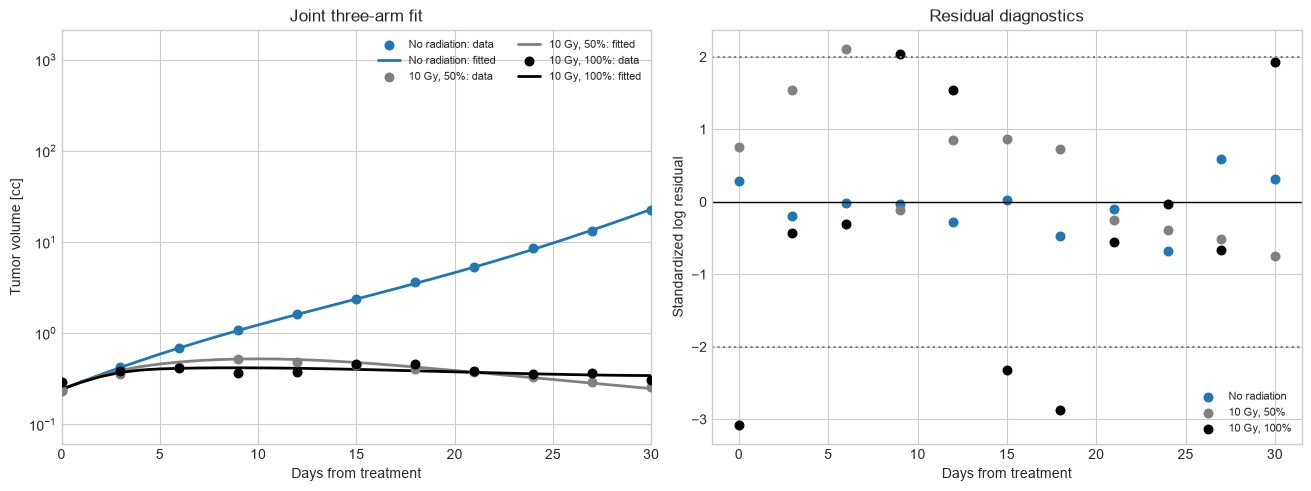

In [12]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.8),
    constrained_layout=True,
)

residual_offset = 0
for arm in DATASET.arms:
    color = ARM_COLORS[arm.name]
    fitted_result = simulate(
        FIT_RESULT.params,
        arm.coverage,
    )
    fitted_curve = fitted_result.total_volume[
        TRUE_PARAMS.treatment_day:
    ]
    fitted_days = np.arange(len(fitted_curve))

    axes[0].scatter(
        arm.relative_days,
        arm.observed_volume,
        color=color,
        s=38,
        label=f"{arm.name}: data",
        zorder=3,
    )
    axes[0].plot(
        fitted_days,
        fitted_curve,
        color=color,
        lw=2,
        label=f"{arm.name}: fitted",
    )

    n_points = len(arm.relative_days)
    arm_residuals = FIT_RESULT.residuals[
        residual_offset:residual_offset + n_points
    ]
    residual_offset += n_points
    axes[1].scatter(
        arm.relative_days,
        arm_residuals,
        color=color,
        s=38,
        label=arm.name,
    )

axes[0].set(
    xlim=(0, 30),
    yscale="log",
    xlabel="Days from treatment",
    ylabel="Tumor volume [cc]",
    title="Joint three-arm fit",
)
axes[0].legend(fontsize=8, ncol=2)

axes[1].axhline(0.0, color="black", lw=1)
axes[1].axhline(2.0, color="0.5", ls=":")
axes[1].axhline(-2.0, color="0.5", ls=":")
axes[1].set(
    xlabel="Days from treatment",
    ylabel="Standardized log residual",
    title="Residual diagnostics",
)
axes[1].legend(fontsize=8)
plt.show()


## 12. Local identifiability: Jacobian과 correlation

Least Squares 해 $u^\star$에서 residual Jacobian은

$$
J_{ij}
=
\left.
\frac{\partial r_i}{\partial u_j}
\right|_{u=u^\star}.
\tag{29}
$$

Gauss–Newton 근사에서

$$
\operatorname{Cov}(u)
\approx
s_r^2(J^\top J)^+,
\qquad
s_r^2=
\frac{\|\mathbf r\|_2^2}{N-p},
\tag{30}
$$

여기서 $+$는 Moore–Penrose pseudo-inverse입니다.

Correlation은

$$
\operatorname{Corr}_{jk}
=
\frac{\operatorname{Cov}_{jk}}
{\sqrt{\operatorname{Cov}_{jj}\operatorname{Cov}_{kk}}}.
\tag{31}
$$

$|\operatorname{Corr}_{jk}|\approx1$이면 두 파라미터가 서로 보상하며 유사한 curve를 만들 수 있다는 뜻입니다. 또한 $J$의 singular-value condition number가 크면 local inverse problem이 ill-conditioned입니다.


In [13]:
LOCAL_SUMMARY, PARAMETER_CORRELATION, SINGULAR_VALUES = (
    local_uncertainty_summary(FIT_RESULT)
)

display(LOCAL_SUMMARY)
display(PARAMETER_CORRELATION)
print("Jacobian singular values:", SINGULAR_VALUES)
print(
    "Jacobian condition number:",
    SINGULAR_VALUES[0] / SINGULAR_VALUES[-1],
)


,parameter,estimate,approx_log_se,approx_relative_se
0,mu,0.216114,0.012309,0.012309
1,omega,0.137733,0.108513,0.108513
2,psi,298.175621,0.094196,0.094196
3,kappa,1.152695,0.120635,0.120635


,mu,omega,psi,kappa
mu,1.000000,0.828422,-0.830097,0.570328
omega,0.828422,1.000000,-0.910225,0.921761
psi,-0.830097,-0.910225,1.000000,-0.749839
kappa,0.570328,0.921761,-0.749839,1.000000


Jacobian singular values: [469.66217432  69.440102    23.75243714   7.03271766]
Jacobian condition number: 66.78245841026308


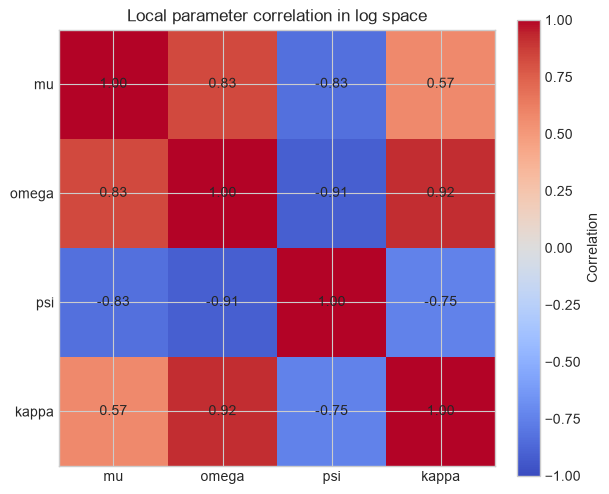

In [14]:
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
image = ax.imshow(
    PARAMETER_CORRELATION.to_numpy(),
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)
ax.set_xticks(
    np.arange(len(FIT_SPECS)),
    labels=[spec.name for spec in FIT_SPECS],
)
ax.set_yticks(
    np.arange(len(FIT_SPECS)),
    labels=[spec.name for spec in FIT_SPECS],
)
for row in range(len(FIT_SPECS)):
    for col in range(len(FIT_SPECS)):
        ax.text(
            col,
            row,
            f"{PARAMETER_CORRELATION.iloc[row, col]:.2f}",
            ha="center",
            va="center",
        )
ax.set_title("Local parameter correlation in log space")
fig.colorbar(image, ax=ax, label="Correlation")
plt.show()


## 13. Profile cost

Local covariance는 목적함수가 quadratic이라는 근사에 의존합니다. Nonlinear ridge를 확인하기 위해 parameter $j$를 값 $q$에 고정하고 나머지를 다시 최적화합니다.

$$
\chi^2_{\mathrm{prof},j}(q)
=
\min_{\theta_{-j}}
\chi^2(\theta_j=q,\theta_{-j}).
\tag{32}
$$

최적점 대비 profile cost는

$$
\Delta\chi_j^2(q)
=
\chi^2_{\mathrm{prof},j}(q)
-
\chi^2_{\min}.
\tag{33}
$$

곡선이 평평하면 해당 파라미터는 넓은 범위에서 다른 파라미터로 보상될 수 있습니다. 참고선 $\Delta\chi^2=3.84$는 regular one-parameter likelihood 조건에서 근사적인 95% 기준입니다.


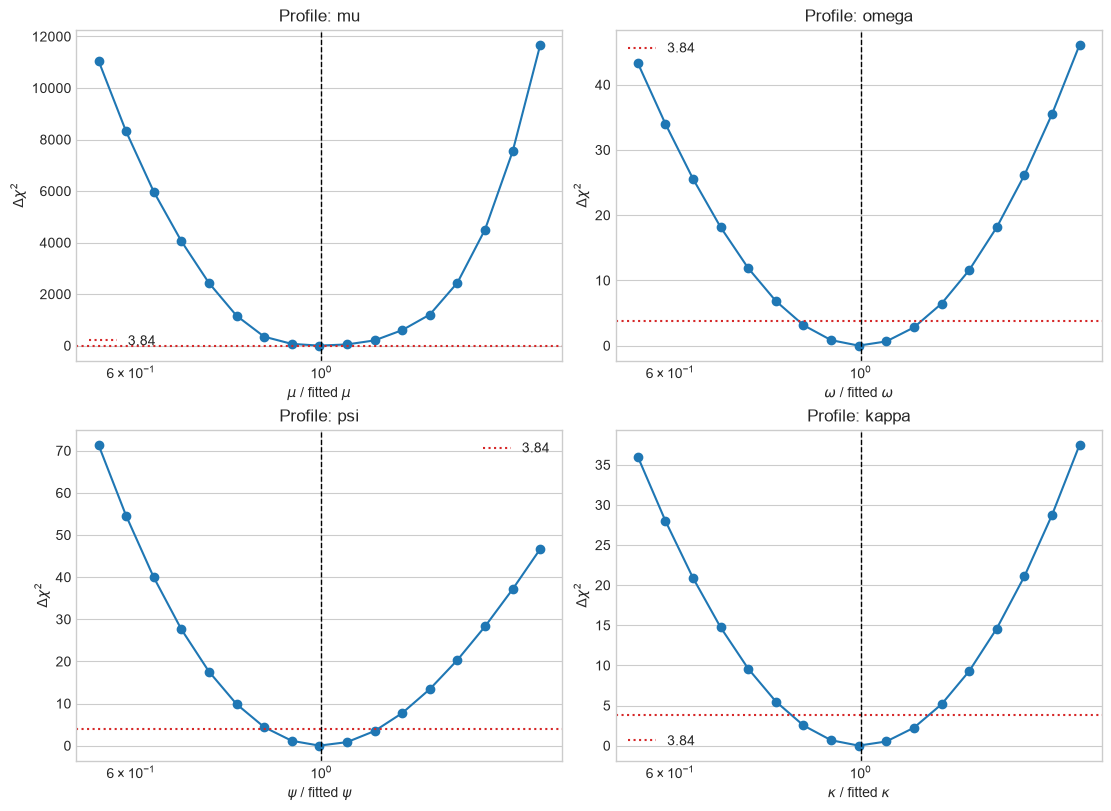

In [15]:
PROFILE_FACTORS = np.exp(
    np.linspace(np.log(0.55), np.log(1.80), 17)
)
PROFILE_RESULTS = pd.concat(
    [
        profile_parameter(
            index,
            dataset=DATASET,
            base_params=TRUE_PARAMS,
            fit_result=FIT_RESULT,
            fit_specs=FIT_SPECS,
            relative_factors=PROFILE_FACTORS,
        )
        for index in range(len(FIT_SPECS))
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11, 8),
    constrained_layout=True,
)
for ax, spec in zip(axes.flat, FIT_SPECS, strict=True):
    subset = PROFILE_RESULTS[
        PROFILE_RESULTS["parameter"] == spec.name
    ]
    ax.plot(
        subset["relative_to_hat"],
        subset["delta_chi2"],
        marker="o",
    )
    ax.axhline(3.84, color="tab:red", ls=":", label="3.84")
    ax.axvline(1.0, color="black", ls="--", lw=1)
    ax.set(
        xscale="log",
        xlabel=rf"{spec.label} / fitted {spec.label}",
        ylabel=r"$\Delta\chi^2$",
        title=f"Profile: {spec.name}",
    )
    ax.legend()
plt.show()


## 14. 반복 noise realizations

한 seed에서 좋은 결과가 나오는 것은 충분하지 않습니다. 같은 true parameter에서 새로운 noise를 반복 생성하고 전체 DE → LS fitting을 다시 수행합니다.

반복 $b=1,\ldots,B$에 대해

$$
\operatorname{RE}_{b,j}
=
100\,
\frac{
\widehat\theta_{b,j}-\theta_j^{true}
}{
\theta_j^{true}
}
\tag{34}
$$

를 계산합니다.

이 분포가 넓거나 bound에 자주 닿으면 point fit이 성공하더라도 해당 파라미터의 실용적 identifiability는 약합니다.


,parameter,mean_fitted,std_fitted,mean_abs_relative_error_pct,max_abs_relative_error_pct
0,kappa,1.052075,0.118240,7.155377,28.018872
1,mu,0.217095,0.002506,0.900502,2.428411
2,omega,0.132215,0.013671,7.830099,21.522863
3,psi,305.303926,32.704346,9.120048,21.167159


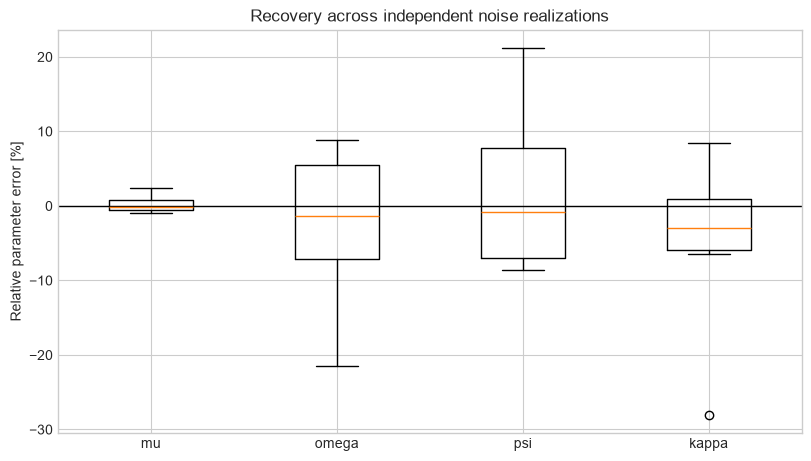

In [16]:
REPEATED_RECOVERY = repeated_noise_recovery(
    range(101, 109),
    true_params=TRUE_PARAMS,
    relative_days=OBSERVATION_DAYS,
    log_sigma=0.06,
    arms=ARMS,
    fit_specs=FIT_SPECS,
)

display(
    REPEATED_RECOVERY.groupby("parameter", as_index=False).agg(
        mean_fitted=("fitted", "mean"),
        std_fitted=("fitted", "std"),
        mean_abs_relative_error_pct=(
            "abs_relative_error_pct",
            "mean",
        ),
        max_abs_relative_error_pct=(
            "abs_relative_error_pct",
            "max",
        ),
    )
)

fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
box_data = [
    REPEATED_RECOVERY.loc[
        REPEATED_RECOVERY["parameter"] == spec.name,
        "relative_error_pct",
    ].to_numpy()
    for spec in FIT_SPECS
]
ax.boxplot(
    box_data,
    tick_labels=[spec.name for spec in FIT_SPECS],
)
ax.axhline(0.0, color="black", lw=1)
ax.set(
    ylabel="Relative parameter error [%]",
    title="Recovery across independent noise realizations",
)
plt.show()


## 15. 실제 digitized Figure 4 데이터로 교체하는 방법

실제 데이터는 long-format CSV로 정리하는 것이 좋습니다.

| arm | coverage | dose_gy | treatment_day | day_from_treatment | volume_cc | log_sigma |
|---|---:|---:|---:|---:|---:|---:|
| No radiation | 0.0 | 0 | 10 | 0 | ... | ... |
| No radiation | 0.0 | 0 | 10 | 3 | ... | ... |
| 10 Gy, 50% | 0.5 | 10 | 10 | 0 | ... | ... |
| 10 Gy, 100% | 1.0 | 10 | 10 | 0 | ... | ... |

원 논문의 error bar가 SEM이면 작은 오차에서

$$
\sigma_{\log V,i}
\approx
\frac{\operatorname{SEM}_i}{V_i}
\tag{35}
$$

로 변환할 수 있습니다. 아래 실제 데이터 loader는 arm별 scalar noise뿐 아니라 각 측정점의 `log_sigma`도 그대로 residual weighting에 사용합니다.

`radioimmune_modeling.dataset_from_frame`은 같은 fitting pipeline에 실제 DataFrame을 연결합니다. `dose_gy`와 `treatment_day`는 arm별로 생략하면 base parameter를 사용합니다.


In [17]:
REAL_DATA_COLUMNS = (
    "arm",
    "coverage",
    "dose_gy",
    "treatment_day",
    "day_from_treatment",
    "volume_cc",
    "log_sigma",
)
REAL_DATA_COLUMNS

# Usage after digitization:
#
# real_frame = pd.read_csv("figure4_digitized.csv")
# real_dataset = dataset_from_frame(
#     real_frame,
#     p=TRUE_PARAMS,
# )
# real_fit = fit_dataset(
#     real_dataset,
#     base_params=TRUE_PARAMS,
#     fit_specs=FIT_SPECS,
#     seed=2026,
# )


('arm',
 'coverage',
 'dose_gy',
 'treatment_day',
 'day_from_treatment',
 'volume_cc',
 'log_sigma')

## 16. 실제 환자 fitting으로 확장할 때

Figure 4의 세 arm은 동일 조건의 동물 집단을 비교하기 때문에 네 biological parameter를 공유할 수 있습니다. 실제 환자 자료에서는 다음 구분이 필요합니다.

### 고정 또는 population-level parameter

$$
\alpha_T,\beta_T,\alpha_L,\beta_L,\lambda_T,\lambda_L,\lambda_A
$$

### 환자별 parameter 후보

$$
\mu_i,\quad
\kappa_i,\quad
V_{\mathrm{RT},i}
$$

### 충분한 dose/coverage variation이 있을 때만 환자별로 허용

$$
\omega_i,\quad\psi_i.
$$

환자 한 명의 volume trajectory 하나만으로 $\mu,\omega,\psi,\kappa$를 모두 자유롭게 추정하면 서로 다른 parameter 조합이 같은 curve를 만들 가능성이 큽니다. 실제 환자 단계에서는 cohort-level shared parameter와 patient-level random effect를 갖는 hierarchical formulation이 더 적절합니다.


## 17. 요약

이 노트북의 fitting workflow는

$$
\begin{aligned}
\text{three-arm data}
&\longrightarrow \text{log residual}\\
&\longrightarrow \text{Differential Evolution}\\
&\longrightarrow \text{Least Squares}\\
&\longrightarrow \text{identifiability diagnostics}
\end{aligned}
\tag{36}
$$

입니다.

핵심 결정은 다음과 같습니다.

1. `no RT`, `10 Gy / 50%`, `10 Gy / 100%`를 동시에 fitting
2. fitting parameter는 $(\mu,\omega,\psi,\kappa)$
3. $\rho$와 radiosensitivity/decay parameter는 고정
4. optimizer는 log-parameter 공간에서 실행
5. multiplicative noise에 맞춰 standardized log residual 사용
6. synthetic recovery에서는 prior 없이 데이터 자체의 정보량 확인
7. point estimate뿐 아니라 correlation, singular values, profile cost, repeated-noise recovery를 함께 평가


Forward model, dataset construction, optimization, and diagnostics are implemented generically in `src/radioimmune_modeling/`; the three-arm Figure 4 setup is only one configured example.